# 05.01 — Baseline Model
**Goal:** Train the first XGBoost model with default parameters.
Establish a performance baseline to beat in experiments.

**Train:** 2024 Won cohort
**Evaluate on:** 2025 Won cohort (decided labels only)


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

import json
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

from src.features.builder import get_feature_columns
from src.models.train import cross_validate, train_final_model, find_optimal_threshold, assign_risk_tier, DEFAULT_PARAMS
from src.models.evaluate import evaluate_model, plot_feature_importance, threshold_analysis, plot_calibration

FEATURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Load Feature Tables

In [2]:

import pyarrow.parquet as pq

train_df = pd.read_parquet(FEATURES / 'train_2024.parquet')
test_df  = pd.read_parquet(FEATURES / 'test_2025.parquet')

with open(FEATURES / 'feature_cols.json') as f:
    feature_cols = json.load(f)

# Test set: only rows with decided labels
test_decided = test_df[test_df['churn_label'].notna()].copy()
test_decided['churn_label'] = test_decided['churn_label'].astype(int)

X_train = train_df[feature_cols]
y_train = train_df['churn_label'].astype(int)
X_test  = test_decided[feature_cols]
y_test  = test_decided['churn_label']

print(f"Training:  {X_train.shape} | churn={y_train.mean()*100:.2f}%")
print(f"Test:      {X_test.shape}  | churn={y_test.mean()*100:.2f}%")
print(f"Features:  {len(feature_cols)}")
print(f"scale_pos_weight: {(y_train==0).sum()/(y_train==1).sum():.1f}")


Training:  (30946, 91) | churn=9.64%
Test:      (32726, 91)  | churn=78.88%
Features:  91
scale_pos_weight: 9.4


## 5-Fold Cross-Validation on Training Set

In [3]:

print("Running 5-fold cross-validation...")
cv_results = cross_validate(X_train, y_train, params=DEFAULT_PARAMS, n_splits=5)


Running 5-fold cross-validation...
  Fold 1: PR-AUC=0.9338  ROC-AUC=0.9917  F1=0.9147
  Fold 2: PR-AUC=0.9511  ROC-AUC=0.9948  F1=0.9297
  Fold 3: PR-AUC=0.9613  ROC-AUC=0.9931  F1=0.9388
  Fold 4: PR-AUC=0.9655  ROC-AUC=0.9946  F1=0.9391
  Fold 5: PR-AUC=0.9538  ROC-AUC=0.9950  F1=0.9368

  CV Summary (5-fold):
  PR-AUC  = 0.9531 ± 0.0109
  ROC-AUC = 0.9938 ± 0.0012
  F1      = 0.9318 ± 0.0092


## Train Final Baseline Model

In [4]:

model_v1 = train_final_model(
    X_train, y_train,
    X_val=X_test, y_val=y_test,
    params=DEFAULT_PARAMS,
    model_name='churn_model_v1_baseline'
)


[0]	validation_0-aucpr:0.79829
[50]	validation_0-aucpr:0.79411
[100]	validation_0-aucpr:0.79311
[150]	validation_0-aucpr:0.79575
[200]	validation_0-aucpr:0.79849
[250]	validation_0-aucpr:0.79836
[300]	validation_0-aucpr:0.79630
[350]	validation_0-aucpr:0.79639
[399]	validation_0-aucpr:0.79637
Model saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\models_saved\churn_model_v1_baseline.json


## Evaluate on Test Set

Model Evaluation — v1_baseline
  Threshold used:    0.000
  PR-AUC:            0.7964
  ROC-AUC:           0.5116
  Precision:         0.7890
  Recall:            0.9998
  F1:                0.8820

  Total test customers:  32,726
  Actual churners:       25,814
  Customers flagged:     32,714
  Churners caught:       25,810 (100.0%)
  Churners missed:       4

              precision    recall  f1-score   support

    Retained       0.67      0.00      0.00      6912
     Churned       0.79      1.00      0.88     25814

    accuracy                           0.79     32726
   macro avg       0.73      0.50      0.44     32726
weighted avg       0.76      0.79      0.70     32726



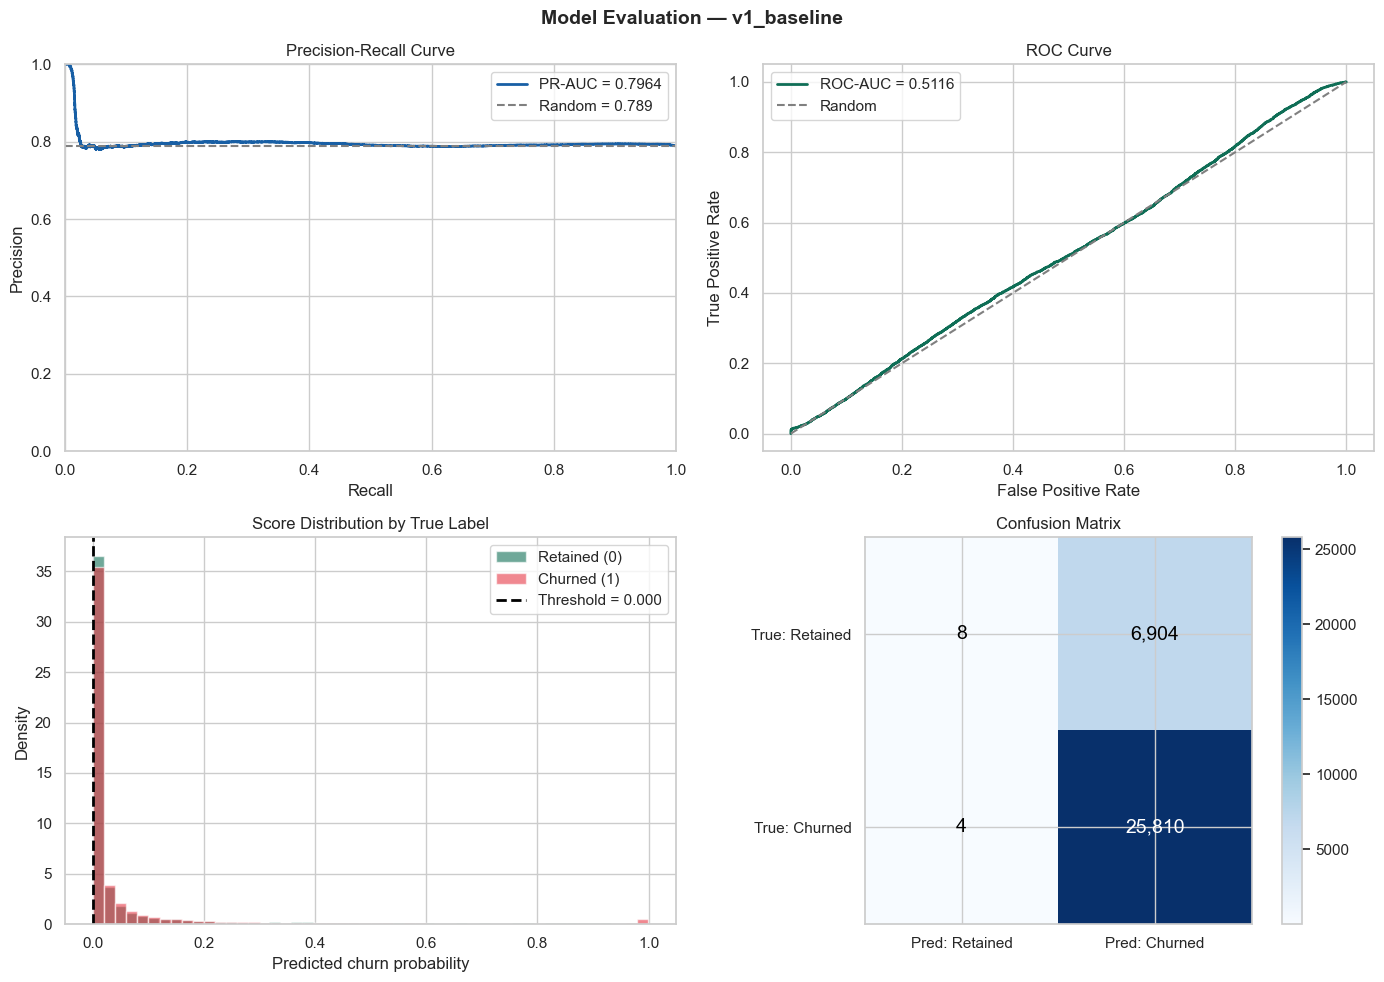

Plot saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\v1_baseline_evaluation.png


In [5]:

baseline_metrics = evaluate_model(
    model_v1, X_test, y_test,
    model_name='v1_baseline',
    save_plots=True
)


## Feature Importance

Saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\v1_baseline_feature_importance.png


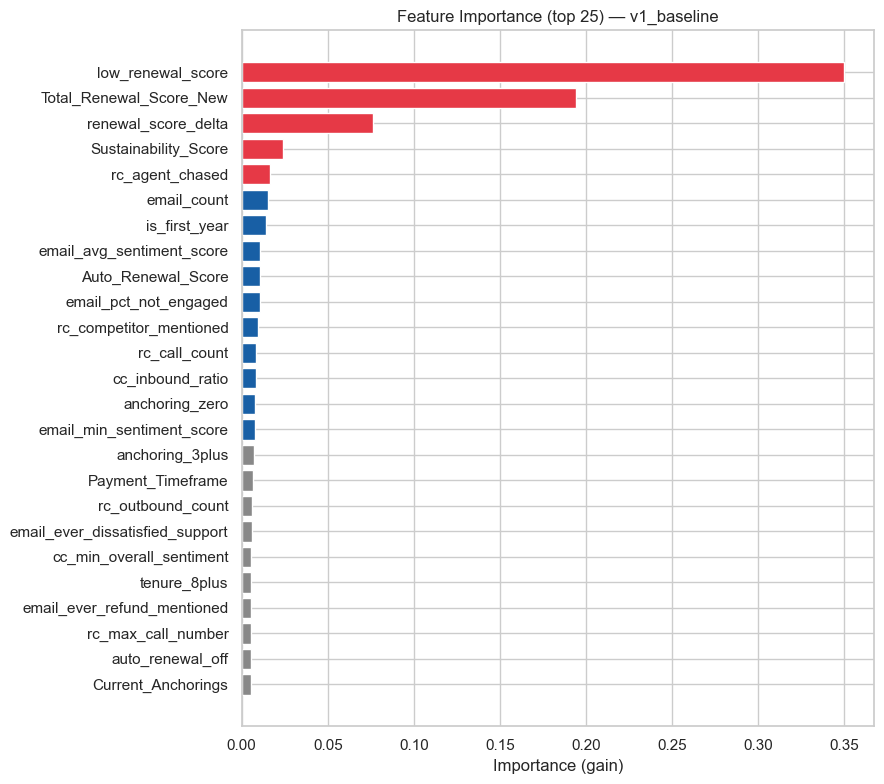


Top 15 features:
                  feature  importance
        low_renewal_score      0.3497
  Total_Renewal_Score_New      0.1939
      renewal_score_delta      0.0761
     Sustainability_Score      0.0238
          rc_agent_chased      0.0163
              email_count      0.0150
            is_first_year      0.0143
email_avg_sentiment_score      0.0108
       Auto_Renewal_Score      0.0108
    email_pct_not_engaged      0.0107
  rc_competitor_mentioned      0.0093
            rc_call_count      0.0085
         cc_inbound_ratio      0.0084
           anchoring_zero      0.0079
email_min_sentiment_score      0.0076


In [6]:

fi_df = plot_feature_importance(model_v1, feature_cols, top_n=25, model_name='v1_baseline')
print("\nTop 15 features:")
print(fi_df.head(15).to_string(index=False))


## Threshold Analysis — Business Tradeoff

Precision/Recall at different thresholds:
 threshold  precision  recall     f1  flagged  caught
    0.0500     0.7980  0.1910 0.3080     6174    4925
    0.1000     0.7920  0.1290 0.2220     4202    3330
    0.1500     0.7870  0.0980 0.1740     3218    2532
    0.2000     0.7870  0.0790 0.1440     2600    2045
    0.2500     0.7850  0.0670 0.1240     2216    1739
    0.3000     0.7820  0.0580 0.1080     1920    1501
    0.3500     0.7830  0.0520 0.0970     1701    1332
    0.4000     0.7880  0.0460 0.0860     1498    1180
    0.4500     0.7890  0.0410 0.0780     1335    1053
    0.5000     0.7870  0.0370 0.0700     1209     952


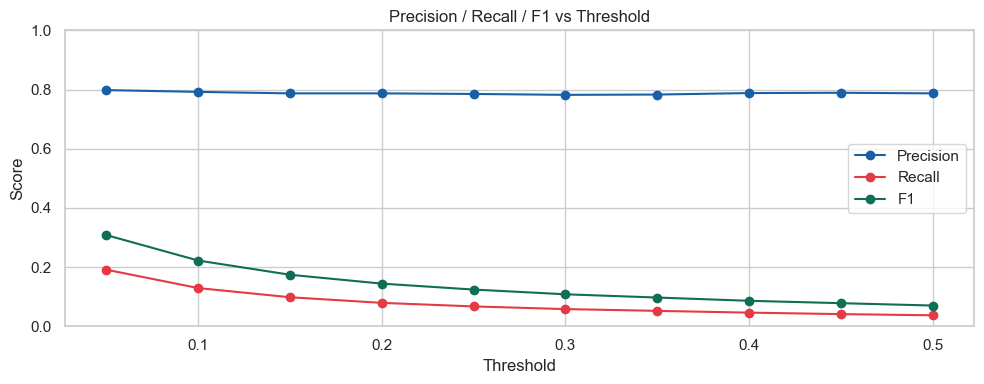

In [7]:

proba = model_v1.predict_proba(X_test)[:,1]
print("Precision/Recall at different thresholds:")
thresh_df = threshold_analysis(y_test.values, proba)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'o-', color='#185FA5', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    'o-', color='#E63946', label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        'o-', color='#0F6E56', label='F1')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORTS / 'v1_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Calibration Check

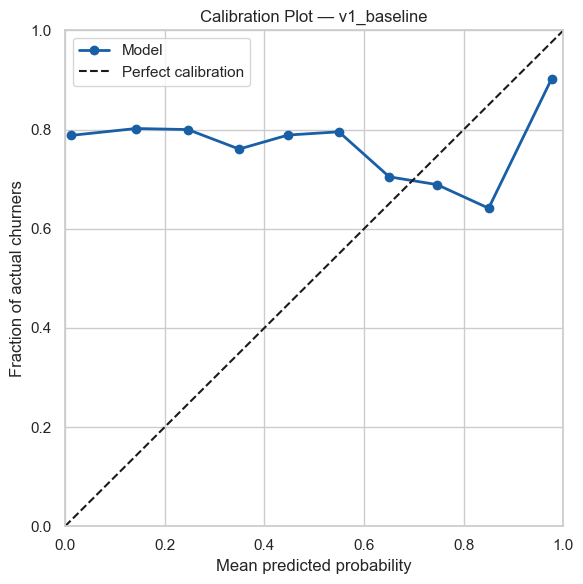

Saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\v1_baseline_calibration.png


In [8]:

plot_calibration(y_test.values, proba, model_name='v1_baseline')
